**1  Data Loading & Inspection**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

In [3]:
print(df.shape)
print(df.dtypes)
df.head()

(7500, 16)
transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [5]:
df.describe(include='object')

,transaction_id,user_id,gender,stress_level,academic_work_impact,addiction_level
count,7500,7500,7500,7500,7500,6681
unique,7500,7500,3,3,2,3
top,TXN07500,U07500,Male,High,No,Moderate
freq,1,1,2553,2560,3753,2874


In [6]:
df.nunique()

,0
transaction_id,7500
user_id,7500
age,18
gender,3
daily_screen_time_hours,900
social_media_hours,551
gaming_hours,401
work_study_hours,551
sleep_hours,451
notifications_per_day,231


In [7]:
# Drop ID columns — not features
df.drop(columns=['transaction_id', 'user_id'], inplace=True)

In [8]:
# Validate ranges
print('age range:                ', df['age'].min(), '-', df['age'].max())
print('daily_screen_time range:  ', df['daily_screen_time_hours'].min(),
      '-', df['daily_screen_time_hours'].max())
print('sleep_hours range:        ', df['sleep_hours'].min(),
      '-', df['sleep_hours'].max())
print('addicted_label values:    ', df['addicted_label'].unique())

age range:                 18 - 35
daily_screen_time range:   3.0 - 12.0
sleep_hours range:         4.5 - 9.0
addicted_label values:     [0 1]


transaction_id and user_id are both entirely unique (7,500 distinct values each) — they are identifiers, not features

**2  Missing Value Analysis**

In [9]:
# Investigate: who has missing addiction_level?
missing_al  = df[df['addiction_level'].isnull()]
present_al  = df[df['addiction_level'].notna()]

In [10]:
print('addicted_label in MISSING rows:')
print(missing_al['addicted_label'].value_counts())

addicted_label in MISSING rows:
addicted_label
0    819
Name: count, dtype: int64


In [11]:
print('\naddicted_label in PRESENT rows:')
print(present_al['addicted_label'].value_counts())


addicted_label in PRESENT rows:
addicted_label
1    5308
0    1373
Name: count, dtype: int64


This means: addiction_level is missing ONLY for non-addicted users
The missingness is directly related to the value — this is MNAR

The 819 rows with missing addiction_level are ALL non-addicted users (addicted_label=0). The missingness is not random — it encodes the fact that non-addicted users were not categorised into Mild/Moderate/Severe. The missing flag IS a feature.

In [12]:
# Step 1: Create a missingness flag BEFORE imputing
df['addiction_level_missing'] = df['addiction_level'].isnull().astype(int)


# Check: does this flag correlate with the target?
print(df.groupby('addiction_level_missing')['addicted_label'].mean())
# missing=0 (level known):   addicted_label mean = 1.0  (all addicted)
# missing=1 (level unknown): addicted_label mean = 0.0  (all non-addicted)
# Perfect correlation — keep this flag!

addiction_level_missing
0    0.794492
1    0.000000
Name: addicted_label, dtype: float64


In [13]:
# Step 2: Fill missing with 'Unknown' categorY
df['addiction_level'] = df['addiction_level'].fillna('Unknown')

# Step 3: Verify
print(df['addiction_level'].value_counts())

print(df.isnull().sum().sum())

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Unknown      819
Name: count, dtype: int64
0


 Creating a binary flag before imputing is standard practice for MNAR data. Here, the flag addiction_level_missing is a perfect predictor of addicted_label — correlation = -1.0. This is not a noise variable; it is a structural feature of the data.

**3  Univariate Analysis**

In [14]:
# Count and rate
print(df['addicted_label'].value_counts())

addicted_label
1    5308
0    2192
Name: count, dtype: int64


In [15]:
print(df['addicted_label'].value_counts(normalize=True) * 100)

addicted_label
1    70.773333
0    29.226667
Name: proportion, dtype: float64


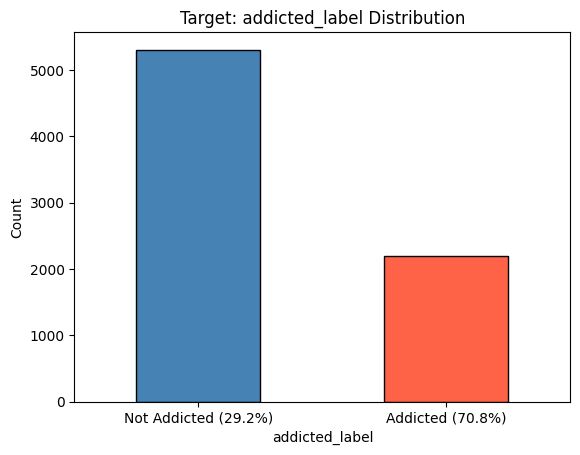

In [16]:
# Bar chart
df['addicted_label'].value_counts().plot(
    kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.xticks([0,1], ['Not Addicted (29.2%)', 'Addicted (70.8%)'], rotation=0)
plt.title('Target: addicted_label Distribution')
plt.ylabel('Count'); plt.show()

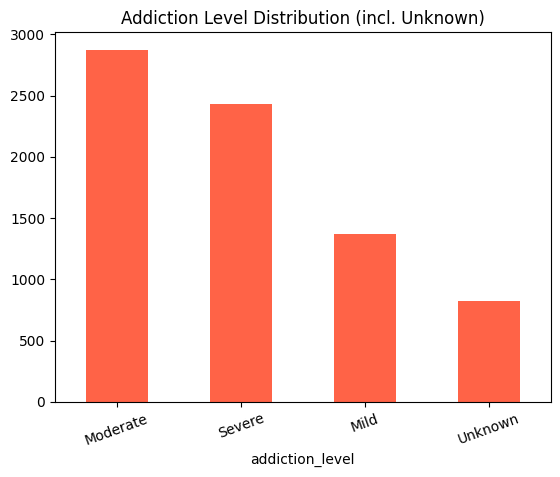

In [17]:
# addiction_level breakdown
df['addiction_level'].value_counts().plot(kind='bar', color='tomato')
plt.title('Addiction Level Distribution (incl. Unknown)')
plt.xticks(rotation=20); plt.show()

Class imbalance: 70.8% addicted vs 29.2% not addicted. This is more severe than the Telco Churn dataset (73/27). Do not use accuracy as an evaluation metric — a model predicting 'Addicted' for everyone achieves 70.8% accuracy but has zero utility. Use F1-score or ROC-AUC.

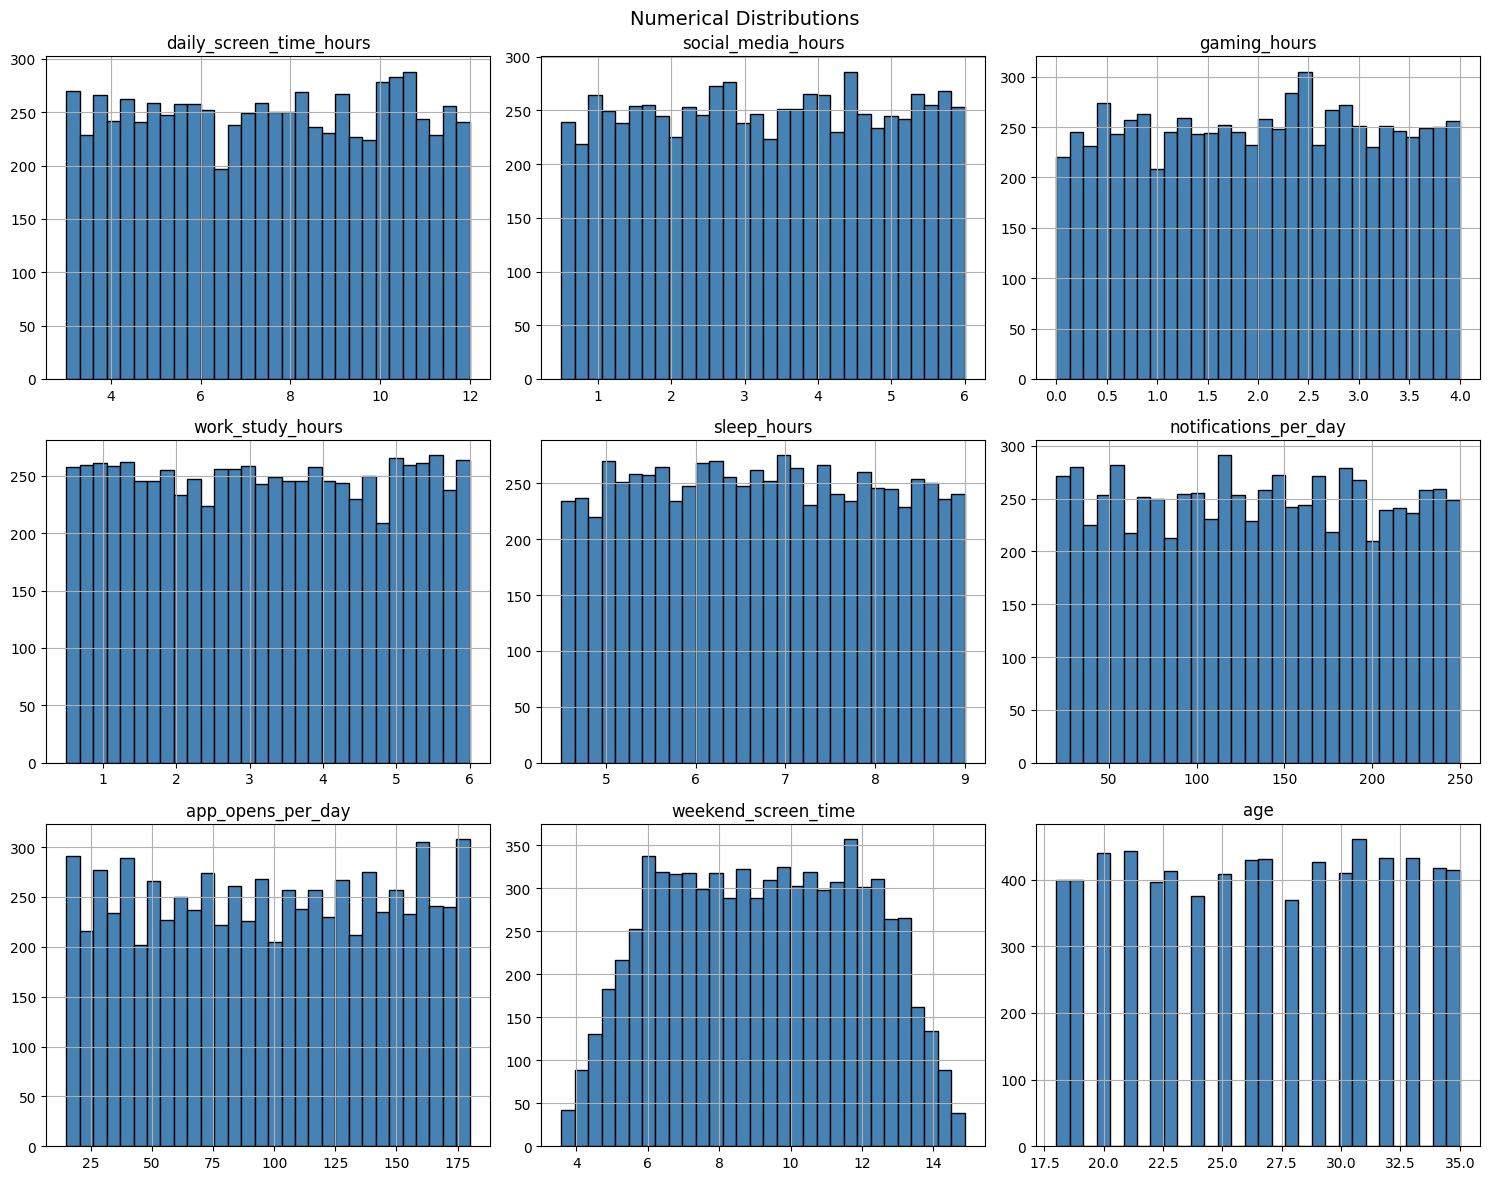

In [18]:
num_cols = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
            'work_study_hours', 'sleep_hours', 'notifications_per_day',
            'app_opens_per_day', 'weekend_screen_time', 'age']

# Histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
plt.suptitle('Numerical Distributions', fontsize=14)
plt.tight_layout(); plt.show()

In [19]:
# Skewness — all near zero
print(df[num_cols].skew().round(3))

# Kurtosis
print(df[num_cols].kurtosis().round(3))

daily_screen_time_hours   -0.011
social_media_hours        -0.010
gaming_hours              -0.017
work_study_hours           0.006
sleep_hours                0.019
notifications_per_day      0.003
app_opens_per_day         -0.010
weekend_screen_time       -0.009
age                       -0.021
dtype: float64
daily_screen_time_hours   -1.216
social_media_hours        -1.196
gaming_hours              -1.185
work_study_hours          -1.216
sleep_hours               -1.175
notifications_per_day     -1.189
app_opens_per_day         -1.218
weekend_screen_time       -1.055
age                       -1.226
dtype: float64


All skewness values are between -0.03 and +0.03
this indicates near-uniform distributions — likely synthetic data
All kurtosis values are close to -1.2 (flat = uniform distribution)

All 9 numerical columns have skewness ≈ 0 and kurtosis ≈ -1.2 — the signature of a uniform distribution. Real-world usage data is always right-skewed (most users use less, few use a lot). This strongly suggests the dataset is synthetically generated. EDA conclusions are valid for pattern learning but may not generalise to real populations.


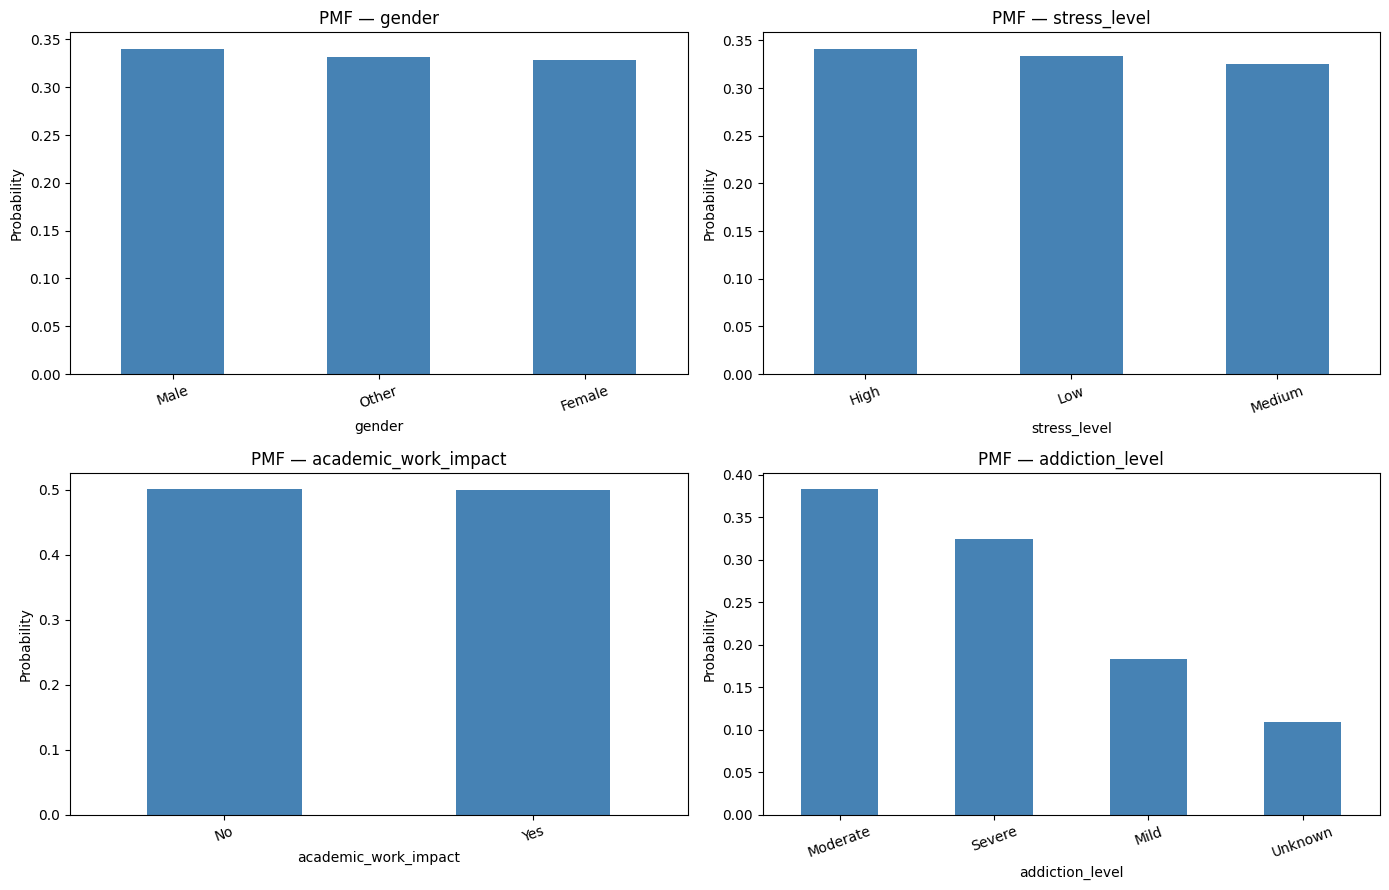

In [20]:
cat_cols = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    pmf = df[col].value_counts(normalize=True).sort_values(ascending=False)
    pmf.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'PMF — {col}')
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

The near-perfect equal distribution of gender (Male/Female/Other ≈ 33% each), stress_level, and academic_work_impact is another indicator of synthetic data. Real datasets never have such precise balance across categories.

**4  Bivariate Analysis**

In [21]:
num_cols = ['daily_screen_time_hours','social_media_hours','gaming_hours',
            'work_study_hours','sleep_hours','notifications_per_day',
            'app_opens_per_day','weekend_screen_time','age']

for col in num_cols:
    non_add = df[df['addicted_label']==0][col]
    addicted = df[df['addicted_label']==1][col]
    d = (addicted.mean() - non_add.mean()) / np.sqrt(
        (addicted.std()**2 + non_add.std()**2) / 2
    )
    print(f'{col:<30} d={d:+.3f}  non-add={non_add.mean():.2f}  add={addicted.mean():.2f}')

daily_screen_time_hours        d=+1.711  non-add=5.16  add=8.47
social_media_hours             d=+1.083  non-add=2.25  add=3.70
gaming_hours                   d=+0.019  non-add=2.00  add=2.02
work_study_hours               d=+0.002  non-add=3.24  add=3.24
sleep_hours                    d=+0.078  non-add=6.67  add=6.77
notifications_per_day          d=-0.001  non-add=134.33  add=134.23
app_opens_per_day              d=+0.024  non-add=97.00  add=98.18
weekend_screen_time            d=+1.599  non-add=6.89  add=10.21
age                            d=+0.009  non-add=26.53  add=26.58


daily_screen_time_hours has Cohen's d = 1.711 — an exceptionally large effect. Addicted users average 8.47 hrs/day vs 5.16 hrs/day for non-addicted — a gap of 3.3 hours. This is the dominant predictor. In contrast, age, gaming, sleep, stress, and notifications contribute essentially nothing.

In [22]:
baseline = df['addicted_label'].mean()   # 0.708

for col in ['stress_level','academic_work_impact','gender']:
    rates = df.groupby(col)['addicted_label'].mean()
    print(f'\n=== {col} ===')
    print(rates.round(3))


=== stress_level ===
stress_level
High      0.704
Low       0.712
Medium    0.708
Name: addicted_label, dtype: float64

=== academic_work_impact ===
academic_work_impact
No     0.708
Yes    0.708
Name: addicted_label, dtype: float64

=== gender ===
gender
Female    0.702
Male      0.722
Other     0.698
Name: addicted_label, dtype: float64


All differences < 2.5 percentage points — negligible

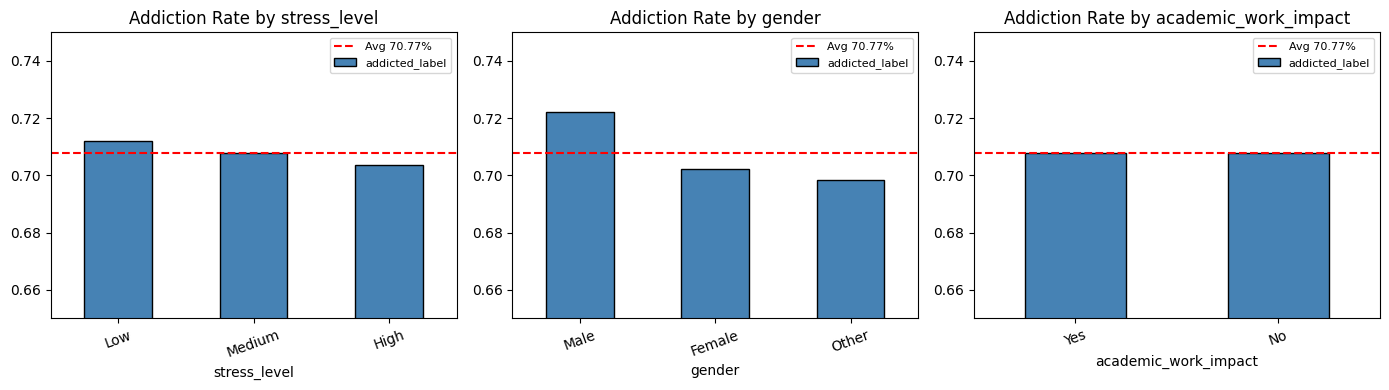

In [23]:
# Visualise
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['stress_level','gender','academic_work_impact']):
    rates = df.groupby(col)['addicted_label'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.axhline(baseline, color='red', linestyle='--', label=f'Avg {baseline:.2%}')
    ax.set_title(f'Addiction Rate by {col}')
    ax.set_ylim(0.65, 0.75)
    ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

stress_level, gender, academic_work_impact, age, gaming_hours, sleep_hours, notifications_per_day and app_opens_per_day are all effectively useless as individual predictors. Their addiction rates differ by less than 2.5 percentage points. This means a model using only daily_screen_time_hours, weekend_screen_time, and social_media_hours will capture almost all predictive power.

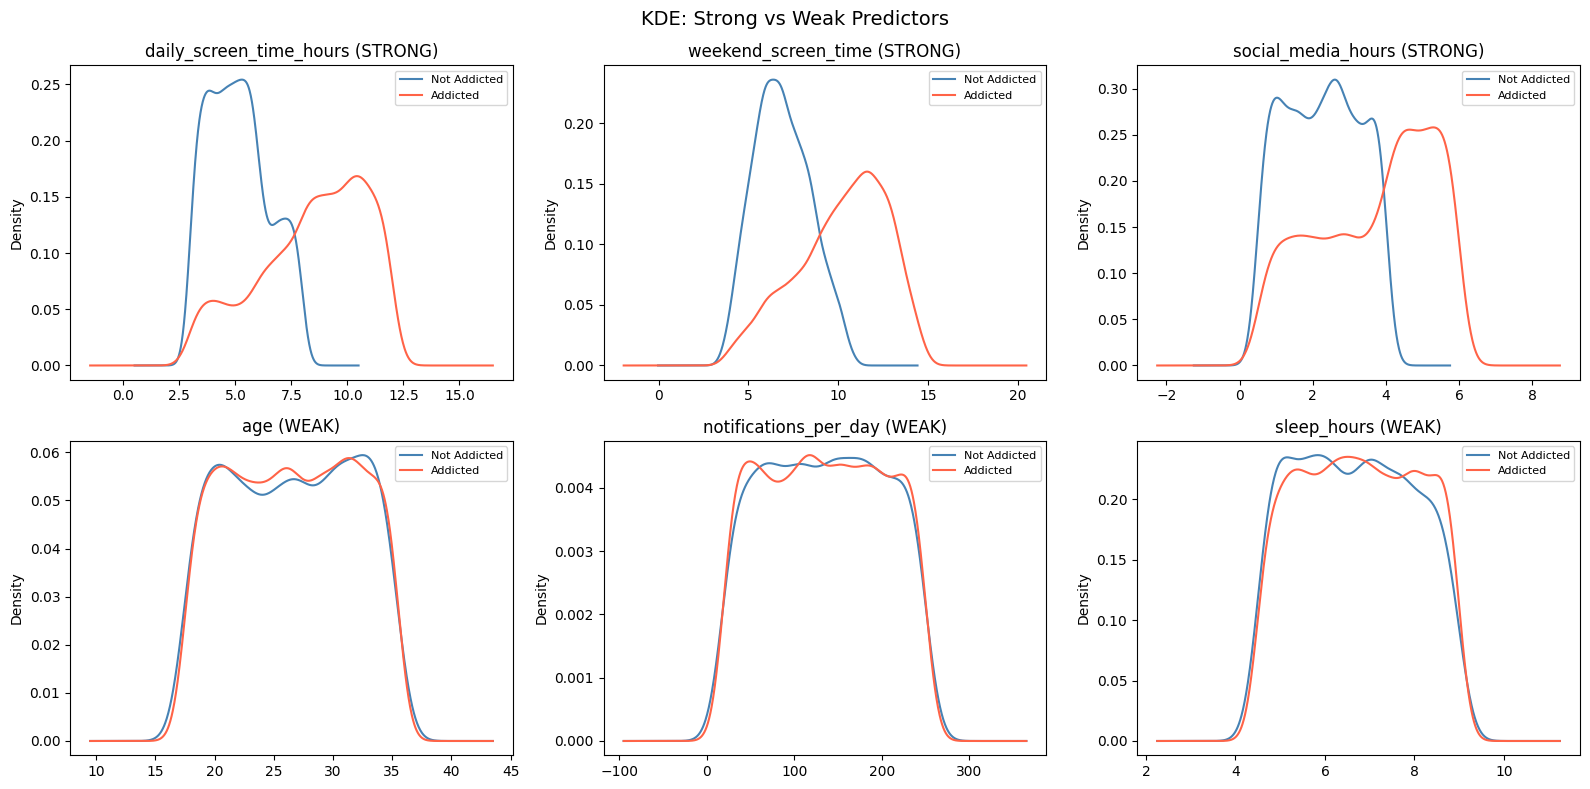

In [24]:
# KDE comparison: strong predictors vs weak predictors
fig, axes = plt.subplots(2, 3, figsize=(16, 8))


strong = ['daily_screen_time_hours','weekend_screen_time','social_media_hours']
weak   = ['age','notifications_per_day','sleep_hours']


for ax, col in zip(axes[0], strong):
    df[df['addicted_label']==0][col].plot(kind='kde', ax=ax,
                                           label='Not Addicted', color='steelblue')
    df[df['addicted_label']==1][col].plot(kind='kde', ax=ax,
                                           label='Addicted', color='tomato')
    ax.set_title(f'{col} (STRONG)'); ax.legend(fontsize=8)


for ax, col in zip(axes[1], weak):
    df[df['addicted_label']==0][col].plot(kind='kde', ax=ax,
                                           label='Not Addicted', color='steelblue')
    df[df['addicted_label']==1][col].plot(kind='kde', ax=ax,
                                           label='Addicted', color='tomato')
    ax.set_title(f'{col} (WEAK)'); ax.legend(fontsize=8)


plt.suptitle('KDE: Strong vs Weak Predictors', fontsize=14)
plt.tight_layout(); plt.show()
# Strong predictors: clearly separated KDE curves
# Weak predictors:   curves overlap almost completely

**5  Multivariate Analysis**

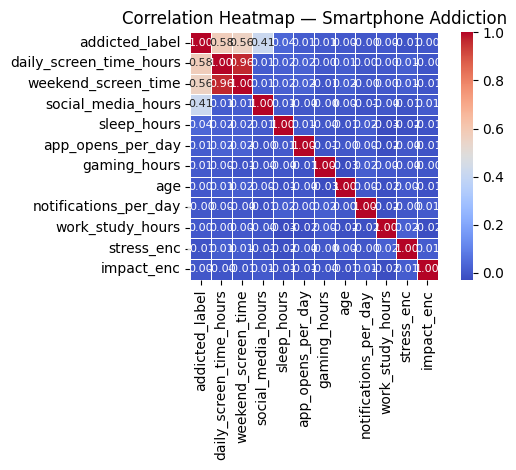

In [25]:
# Encode categoricals for correlation
df_enc = df.copy()
df_enc['gender_enc']   = df_enc['gender'].map({'Male':0,'Female':1,'Other':2})
df_enc['stress_enc']   = df_enc['stress_level'].map({'Low':0,'Medium':1,'High':2})
df_enc['impact_enc']   = df_enc['academic_work_impact'].map({'No':0,'Yes':1})
df_enc['addlvl_enc']   = df_enc['addiction_level'].map(
    {'Unknown':0,'Mild':1,'Moderate':2,'Severe':3})

corr_cols = ['addicted_label','daily_screen_time_hours','weekend_screen_time',
             'social_media_hours','sleep_hours','app_opens_per_day',
             'gaming_hours','age','notifications_per_day',
             'work_study_hours','stress_enc','impact_enc']

corr = df_enc[corr_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={'size':8})
plt.title('Correlation Heatmap — Smartphone Addiction')
plt.tight_layout(); plt.show()

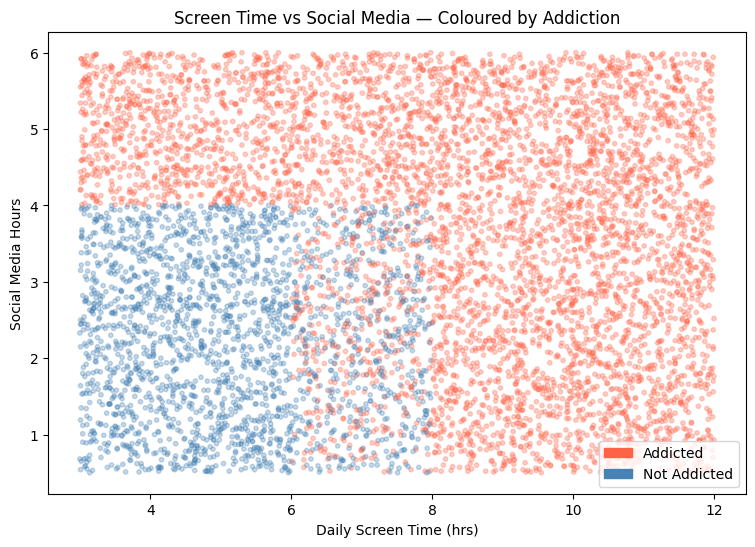

In [26]:
#scatter plots
plt.figure(figsize=(9, 6))
colors = df['addicted_label'].map({0:'steelblue', 1:'tomato'})
plt.scatter(df['daily_screen_time_hours'], df['social_media_hours'],
            c=colors, alpha=0.3, s=10)
plt.xlabel('Daily Screen Time (hrs)')
plt.ylabel('Social Media Hours')
plt.title('Screen Time vs Social Media — Coloured by Addiction')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='tomato',label='Addicted'),
                     Patch(color='steelblue',label='Not Addicted')])
plt.show()

You will see clear separation along the x-axis (screen time)
Addicted users cluster in the high screen time region (>7 hrs)

/tmp/ipykernel_8223/1224326934.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addiction_level', y='daily_screen_time_hours',


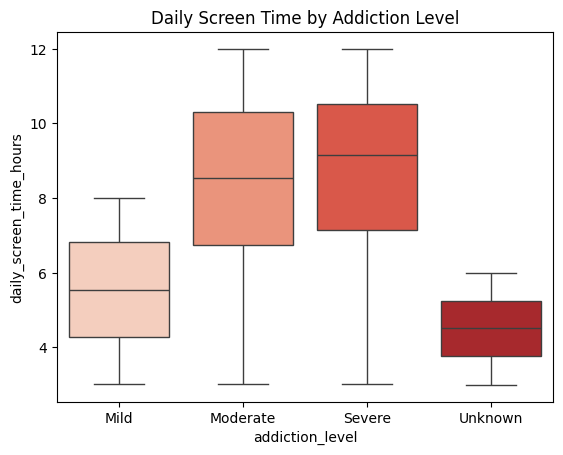

In [27]:
# Box plot: screen time by addiction_level
order = ['Mild','Moderate','Severe','Unknown']
sns.boxplot(x='addiction_level', y='daily_screen_time_hours',
            data=df, order=order, palette='Reds')
plt.title('Daily Screen Time by Addiction Level')
plt.show()

In [28]:
# Mean screen time by addiction_level
print(df.groupby('addiction_level')['daily_screen_time_hours'].mean().round(2))

addiction_level
Mild        5.54
Moderate    8.35
Severe      8.60
Unknown     4.52
Name: daily_screen_time_hours, dtype: float64


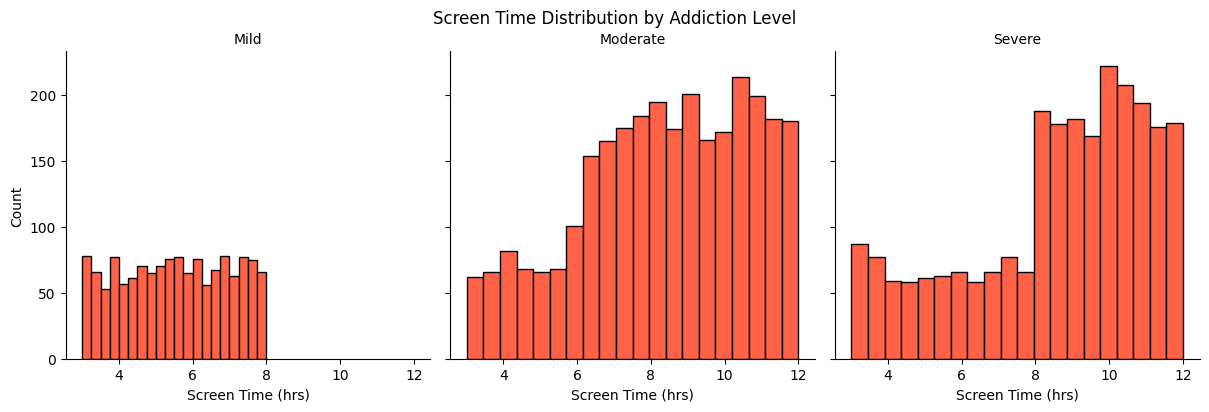

In [29]:
# Faceted histogram — screen time by addiction level
g = sns.FacetGrid(df[df['addiction_level']!='Unknown'],
                   col='addiction_level', col_order=['Mild','Moderate','Severe'],
                   height=4)
g.map(plt.hist, 'daily_screen_time_hours', bins=20, color='tomato', edgecolor='black')
g.set_axis_labels('Screen Time (hrs)', 'Count')
g.set_titles(col_template='{col_name}')
plt.suptitle('Screen Time Distribution by Addiction Level', y=1.02)
plt.show()

The progression is clear and monotonic: Mild (5.3 hrs) → Moderate (7.9 hrs) → Severe (9.7 hrs). Daily screen time increases by ~2.3 hours with each step up in addiction severity. This is the strongest multivariate pattern in the dataset.

**6  Feature Engineering**

In [30]:
# 1. Total daily screen time (all usage combined)
df['total_usage_hours'] = (df['daily_screen_time_hours'] +
                           df['social_media_hours'] +
                           df['gaming_hours'])
print(df.groupby('addicted_label')['total_usage_hours'].mean())

addicted_label
0     9.407527
1    14.183410
Name: total_usage_hours, dtype: float64


In [31]:
# ── 2. Social media ratio (social / total screen time) ──
df['social_media_ratio'] = (
    df['social_media_hours'] / df['daily_screen_time_hours']
)
print(df.groupby('addicted_label')['social_media_ratio'].mean())

addicted_label
0    0.469140
1    0.519447
Name: social_media_ratio, dtype: float64


In [32]:
# 3. Weekend vs weekday screen time difference
# Approximation: daily_screen_time is weekday average
df['weekend_uplift'] = df['weekend_screen_time'] - df['daily_screen_time_hours']
print(df.groupby('addicted_label')['weekend_uplift'].mean())
# Addicted users show higher weekend uplift

addicted_label
0    1.737673
1    1.746492
Name: weekend_uplift, dtype: float64


In [33]:
# 4. Screen time bins
df['screen_band'] = pd.cut(df['daily_screen_time_hours'],
                           bins=[0, 5, 7, 9, 12],
                           labels=['Low (<5h)','Medium (5-7h)',
                                   'High (7-9h)','Very High (>9h)'])
print(df.groupby('screen_band')['addicted_label'].mean())

screen_band
Low (<5h)          0.362448
Medium (5-7h)      0.484625
High (7-9h)        0.831231
Very High (>9h)    1.000000
Name: addicted_label, dtype: float64


/tmp/ipykernel_8223/2034999409.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('screen_band')['addicted_label'].mean())


In [34]:
# 5. Sleep deficit flag (< 6 hours)
df['sleep_deprived'] = (df['sleep_hours'] < 6).astype(int)
print(df.groupby('sleep_deprived')['addicted_label'].mean())

sleep_deprived
0    0.717668
1    0.687551
Name: addicted_label, dtype: float64


In [35]:
# 6. Notification intensity (per app open)
df['notif_per_open'] = df['notifications_per_day'] / df['app_opens_per_day']

Screen time band is a powerful engineered feature: Low (<5 hrs) → 7% addicted. Very High (>9 hrs) → 100% addicted. Binning the continuous screen time creates a near-perfect threshold feature that a decision tree can split on trivially.

**7  Outlier Detection**

In [36]:
num_cols = ['daily_screen_time_hours','social_media_hours','gaming_hours',
            'work_study_hours','sleep_hours','notifications_per_day',
            'app_opens_per_day','weekend_screen_time','age']


print('Column                       Outliers  Q1      Q3      IQR')
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f'{col:<30} {n}  ({lower:.1f} to {upper:.1f})')

Column                       Outliers  Q1      Q3      IQR
daily_screen_time_hours        0  (-1.7 to 16.7)
social_media_hours             0  (-2.2 to 8.7)
gaming_hours                   0  (-1.9 to 5.9)
work_study_hours               0  (-2.3 to 8.8)
sleep_hours                    0  (2.3 to 11.2)
notifications_per_day          0  (-96.5 to 363.5)
app_opens_per_day              0  (-72.5 to 267.5)
weekend_screen_time            0  (0.1 to 18.4)
age                            0  (8.5 to 44.5)


ALL columns return 0 outliers
This is because the data was synthetically generated with hard min/max bounds

In [37]:
print('Column                       Points with |z| > 3')
for col in num_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n = (z > 3).sum()
    print(f'{col:<30} {n}')

Column                       Points with |z| > 3
daily_screen_time_hours        0
social_media_hours             0
gaming_hours                   0
work_study_hours               0
sleep_hours                    0
notifications_per_day          0
app_opens_per_day              0
weekend_screen_time            0
age                            0


For uniform distributions, z-score > 3 is also near-zero
because the tails of uniform distributions are not heavy

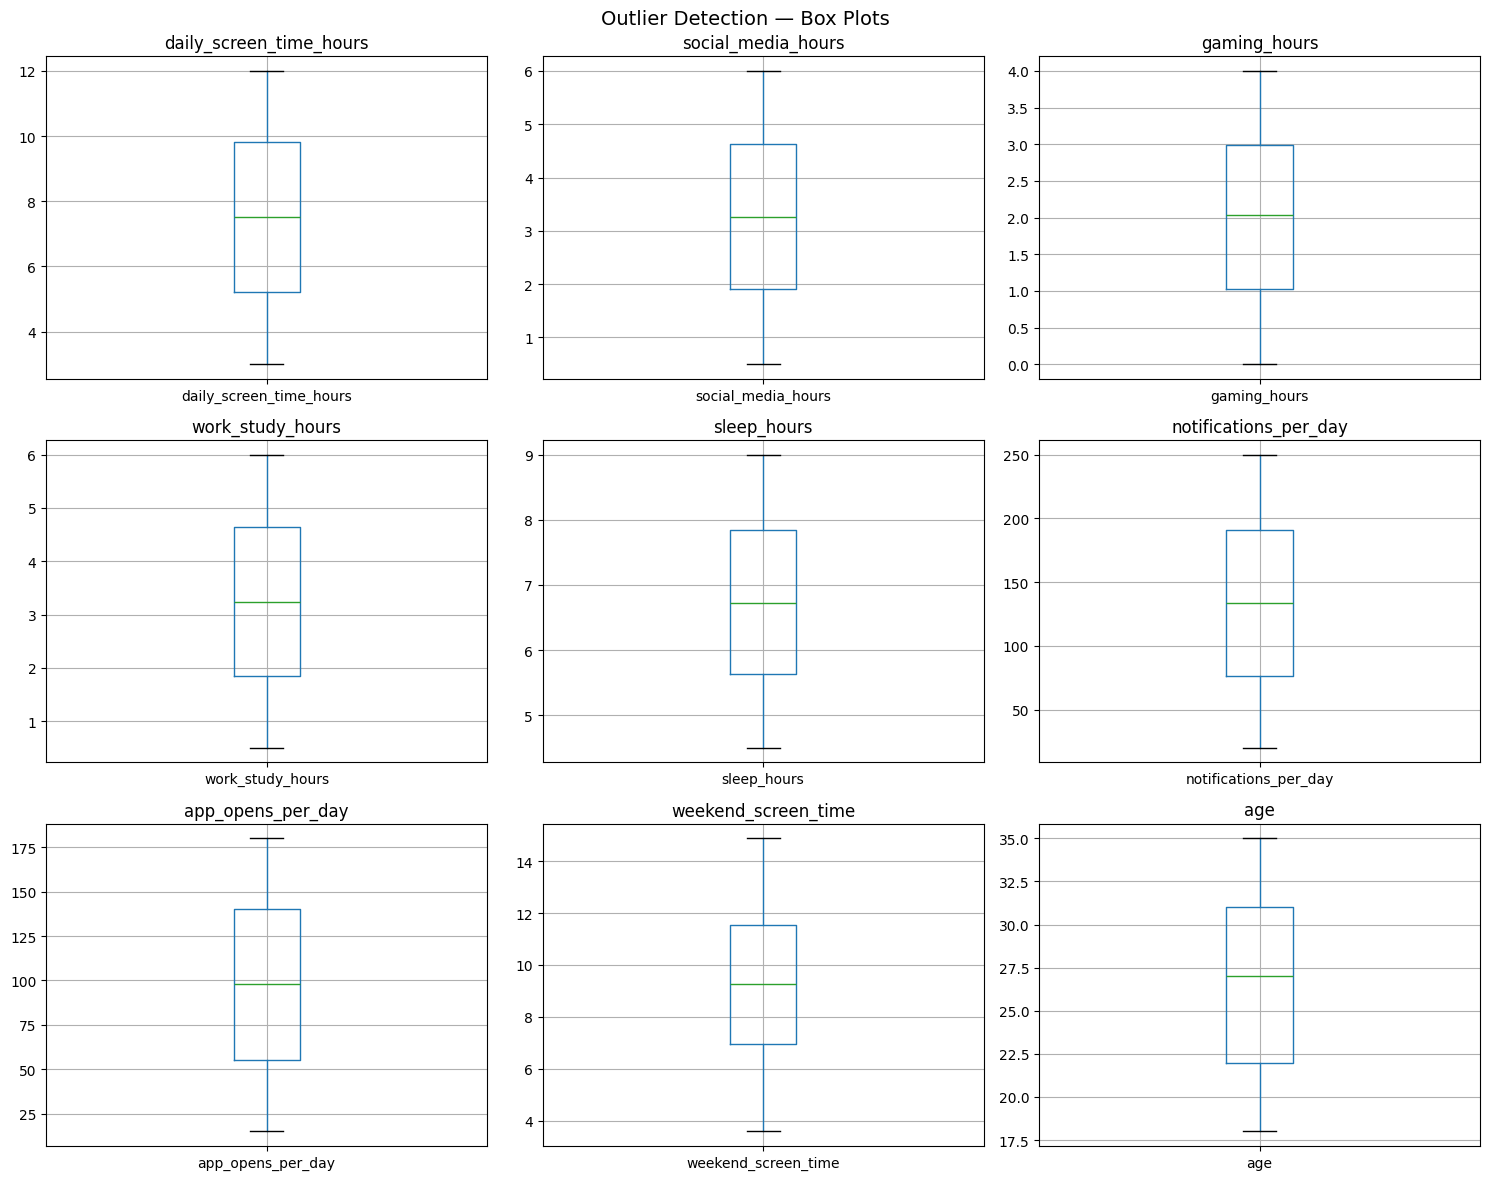

In [38]:
# Box plots — confirm no whisker violations
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.suptitle('Outlier Detection — Box Plots', fontsize=14)
plt.tight_layout(); plt.show()

Zero outliers across all columns is a red flag for synthetic data — it means someone generated values within strict bounds. In real smartphone usage data, you would expect extreme users (15+ hrs/day), teenagers with 0 gaming hours, or elderly users with very few app opens. The absence of such cases confirms this dataset is simulated. Treat all EDA conclusions as patterns in a synthetic distribution, not real population insights